In [24]:
import pandas as pd
import numpy as np
np.random.seed(0) 

## I Datenprofiling

*Hier wird unser Datensatz systematisch analysiert, mit dem Ziel auf folgende Fragen zu antworten:*

Struktur: 
- Welche Spalten gibt es und welche Datentypen (Zahlen, Text, Datum) liegen vor?  
Vollständigkeit: 
- Gibt es fehlende Werte?  
Eindeutigkeit:
- Gibt es doppelte Einträge?  
Verteilung & Spannen: 
- Was ist der Mindest-, Höchst- und Durchschnittswert? 
- Gibt es bereits hier extreme Ausreißer?

In [25]:
luxury_datensatz = pd.read_csv("luxury_cosmetics_fraud_analysis_2025.csv")

luxury_datensatz.head() # Es fällt schon auf, dass ein Wert im Spalte Customer_Age in der 4. Zeile fehlt.

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Time,Customer_Age,Customer_Loyalty_Tier,Location,Store_ID,Product_SKU,Product_Category,Purchase_Amount,Payment_Method,Device_Type,IP_Address,Fraud_Flag,Footfall_Count
0,702bdd9b-9c93-41e3-9dbb-a849b2422080,119dca0b-8554-4b2d-9bec-e964eaf6af97,2025-07-27,04:04:15,56.0,Silver,San Francisco,FLAGSHIP-LA,NEBULA-SERUM-07,Concealer,158.24,Mobile Payment,Desktop,239.249.58.237,0,333
1,2e64c346-36bc-4acf-bc2b-8b0fdf46abc5,299df086-26c4-4708-b6d7-fcaeceb14637,2025-03-14,20:23:23,46.0,Platinum,Zurich,BOUTIQUE-SHANGHAI,STELLAR-FOUND-03,Lipstick,86.03,Credit Card,Tablet,84.49.227.90,0,406
2,29ad1278-70ce-421f-8d81-23816b39f4ac,dfa3d24d-b935-49a5-aa1d-7d57a44d8773,2025-02-20,12:36:02,32.0,Silver,Milan,POPUP-TOKYO,SOLAR-BLUSH-04,Mascara,255.69,Gift Card,Desktop,79.207.35.55,0,96
3,07dc4894-e0eb-48f1-99a7-1942b1973d9b,7a67e184-9369-49ee-aeac-18f5b51b230f,2025-04-25,19:09:43,60.0,Bronze,London,BOUTIQUE-NYC,GALAXIA-SET-08,Serum,282.76,Gift Card,Mobile,176.194.167.253,0,186
4,ae407054-5543-429c-918a-cdcc42ea9782,cf14730a-8f5a-453d-b527-39a278852b27,2025-04-17,14:23:23,NaN,Platinum,Miami,BOUTIQUE-NYC,LUNAR-MASC-02,Serum,205.86,Gift Card,Mobile,166.31.46.111,0,179


In [26]:
# Jetzt kugen wir welches Teil diese fehlende Werde für jeden Spalte darstellen.
missing_value_count = luxury_datensatz.isnull().sum()

print(f"Fehlende Werte für jede Spalte \n {missing_value_count}")

#Wie viel Prozent ist das?
total_cells = np.prod(luxury_datensatz.shape)
total_missing = missing_value_count.sum()

# percent of data that is missing
percent_missing = (total_missing/total_cells) * 100
print("-----------------------------------------------------------------------------------------")
print(f"{percent_missing} Prozent des Datensatzes ist fehlend")

Fehlende Werte für jede Spalte 
 Transaction_ID             0
Customer_ID                0
Transaction_Date           0
Transaction_Time           0
Customer_Age             106
Customer_Loyalty_Tier    106
Location                   0
Store_ID                   0
Product_SKU                0
Product_Category           0
Purchase_Amount            0
Payment_Method           106
Device_Type                0
IP_Address                 0
Fraud_Flag                 0
Footfall_Count             0
dtype: int64
-----------------------------------------------------------------------------------------
0.9317862165963432 Prozent des Datensatzes ist fehlend


### Struktur

Wir schauen uns die Datentypen jeder Spalte an, um zu prüfen, ob sie mit dem erwarteten Typ übereinstimmen (zum Beispiel ob `Transaction_Date` wirklich als Datum erkannt wird oder nur als Text/object vorliegt).

In [27]:
luxury_datensatz.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2133 entries, 0 to 2132
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Transaction_ID         2133 non-null   object 
 1   Customer_ID            2133 non-null   object 
 2   Transaction_Date       2133 non-null   object 
 3   Transaction_Time       2133 non-null   object 
 4   Customer_Age           2027 non-null   float64
 5   Customer_Loyalty_Tier  2027 non-null   object 
 6   Location               2133 non-null   object 
 7   Store_ID               2133 non-null   object 
 8   Product_SKU            2133 non-null   object 
 9   Product_Category       2133 non-null   object 
 10  Purchase_Amount        2133 non-null   float64
 11  Payment_Method         2027 non-null   object 
 12  Device_Type            2133 non-null   object 
 13  IP_Address             2133 non-null   object 
 14  Fraud_Flag             2133 non-null   int64  
 15  Foot

### Eindeutigkeit

Jede Transaktion sollte einen eindeutigen Eintrag darstellen. Wir prüfen deshalb, ob es komplett doppelte Zeilen gibt und ob die Transaction_ID mehrfach vorkommt.

In [28]:
anzahl_duplikate = luxury_datensatz.duplicated().sum()
anzahl_duplikate_id = luxury_datensatz["Transaction_ID"].duplicated().sum()

print(f"Anzahl komplett doppelter Zeilen: {anzahl_duplikate}")
print(f"Anzahl doppelter Transaction_ID: {anzahl_duplikate_id}")

Anzahl komplett doppelter Zeilen: 0
Anzahl doppelter Transaction_ID: 0


### Verteilung & Spannen

Mit describe() betrachten wir Minimum, Maximum, Mittelwert und Quartile der numerischen Spalten, um ein Gefühl für die Wertebereiche zu bekommen.

In [29]:
luxury_datensatz.describe()

,Customer_Age,Purchase_Amount,Fraud_Flag,Footfall_Count
count,2027.000000,2133.000000,2133.000000,2133.000000
mean,41.684262,174.614074,0.030942,272.461791
std,13.718110,72.249043,0.173202,131.113027
min,18.000000,50.260000,0.000000,50.000000
25%,30.000000,113.850000,0.000000,157.000000
50%,42.000000,174.180000,0.000000,269.000000
75%,53.000000,236.360000,0.000000,388.000000
max,65.000000,299.910000,1.000000,500.000000


In [30]:
def iqr_ausreisser(spalte):
    q1 = luxury_datensatz[spalte].quantile(0.25)
    q3 = luxury_datensatz[spalte].quantile(0.75)
    iqr = q3 - q1
    untere_grenze = q1 - 1.5 * iqr
    obere_grenze = q3 + 1.5 * iqr
    ausreisser = luxury_datensatz[(luxury_datensatz[spalte] < untere_grenze) | (luxury_datensatz[spalte] > obere_grenze)]
    print(f"{spalte}: {len(ausreisser)} Ausreißer (Grenzen: {untere_grenze:.2f} bis {obere_grenze:.2f})")

for spalte in ["Purchase_Amount", "Customer_Age", "Footfall_Count"]:
    iqr_ausreisser(spalte)

Purchase_Amount: 0 Ausreißer (Grenzen: -69.92 bis 420.13)
Customer_Age: 0 Ausreißer (Grenzen: -4.50 bis 87.50)
Footfall_Count: 0 Ausreißer (Grenzen: -189.50 bis 734.50)


### Uneinheitliche Einträge

Wir prüfen die kategorischen Spalten auf uneinheitliche Schreibweisen, die eigentlich dieselbe Kategorie meinen würden. Dazu vergleichen wir die Anzahl eindeutiger Werte vor und nach dem Trimmen/Kleinschreiben je Spalte.

In [34]:
kategorische_spalten = ["Customer_Loyalty_Tier", "Location", "Product_Category", "Payment_Method", "Device_Type"]

for spalte in kategorische_spalten:
    vorher = luxury_datensatz[spalte].nunique()
    nachher = luxury_datensatz[spalte].str.strip().str.lower().nunique()
    print(f"{spalte}: {vorher} eindeutige Werte vorher, {nachher} nach Trimmen/Kleinschreiben")

Customer_Loyalty_Tier: 6 eindeutige Werte vorher, 6 nach Trimmen/Kleinschreiben
Location: 20 eindeutige Werte vorher, 20 nach Trimmen/Kleinschreiben
Product_Category: 10 eindeutige Werte vorher, 10 nach Trimmen/Kleinschreiben
Payment_Method: 5 eindeutige Werte vorher, 5 nach Trimmen/Kleinschreiben
Device_Type: 4 eindeutige Werte vorher, 4 nach Trimmen/Kleinschreiben


Die Anzahl eindeutiger Werte ändert sich in keiner Spalte durch Trimmen/Kleinschreiben — es liegen also keine uneinheitlichen Einträge vor.

### Zusammenfassung Datenprofiling

- **Struktur:** 16 Spalten: zwölf Zeichenketten-Spalten (`str`), zwei numerische Spalten (`float64`) und zwei Ganzzahl-Spalten (`int64`). `Transaction_Date` und `Transaction_Time` liegen als Text vor, folgen aber jeweils einem einheitlichen Format (siehe oben).
- **Vollständigkeit:** `Customer_Age`, `Customer_Loyalty_Tier` und `Payment_Method` haben je 106 fehlende Werte (~0,93 % aller Zellen) — das ist das zentrale Datenqualitätsproblem, das die folgenden Quality-Checks systematisch aufdecken sollen.
- **Eindeutigkeit:** Keine doppelten Zeilen und keine doppelten `Transaction_ID`.
- **Verteilung & Spannen:** Alle numerischen Spalten liegen in plausiblen Wertebereichen. Laut IQR-Methode gibt es keine extremen Ausreißer.
- **Uneinheitliche Einträge:** In den kategorischen Spalten wurden keine inkonsistenten Schreibweisen gefunden.

Das Datenprofiling ist damit abgeschlossen. Anders als in einem klassischen Data-Cleaning-Workflow bereinigen wir den Datensatz an dieser Stelle bewusst **nicht**: Die hier gefundenen fehlenden Werte bleiben im Datensatz erhalten, damit die folgenden automatisierten Quality-Checks sie auch tatsächlich als Verstoß erkennen und melden — würde vorher schon bereinigt, würden die Checks nur noch triviale 0-Verstoß-Ergebnisse liefern und nichts mehr über die tatsächliche Datenqualität aussagen. Erst innerhalb der Modellierung in Abschnitt III wird, wo für den Algorithmus technisch zwingend nötig, lokal und nur für die Merkmalsmatrix nachgeholfen.

## II Quality-Checks

Basierend auf den Erkenntnissen aus dem Datenprofiling (Abschnitt I) implementieren wir jetzt fünf automatisierte Quality-Checks auf dem **unveränderten Rohdatensatz** `luxury_datensatz`. Jeder Check prüft eine Regel und liefert die Anzahl der Verstöße zurück. Da bewusst keine Bereinigung vorgeschaltet ist, sollen die Checks die im Profiling gefundenen Probleme — insbesondere die fehlenden Werte — auch tatsächlich als Verstöße aufdecken. Am Ende fassen wir alle Ergebnisse in einem Gesamtbericht zusammen, damit sich die Prüfung jederzeit automatisch wiederholen lässt, z. B. wenn neue Transaktionsdaten dazukommen.

In [35]:
# Hier sammeln wir die Ergebnisse aller Checks, um am Ende einen Gesamtbericht zu erstellen.
qualitaets_ergebnisse = []

def pruefung_protokollieren(name, anzahl_verstoesse):
    bestanden = anzahl_verstoesse == 0
    qualitaets_ergebnisse.append({"Check": name, "Verstoesse": int(anzahl_verstoesse), "Bestanden": bestanden})
    status = "bestanden" if bestanden else "NICHT bestanden"
    print(f"[{status}] {name}: {anzahl_verstoesse} Verstoß/Verstöße")

### 1. Vollständigkeits-Check

Prüft, ob im Rohdatensatz fehlende Werte vorhanden sind. Aus dem Profiling (Abschnitt I) erwarten wir hier einen echten Verstoß: je 106 fehlende Werte in drei Spalten, also 318 insgesamt.

In [36]:
def check_vollstaendigkeit(df):
    anzahl_verstoesse = df.isnull().sum().sum()
    pruefung_protokollieren("1. Vollständigkeit (keine fehlenden Werte)", anzahl_verstoesse)

check_vollstaendigkeit(luxury_datensatz)

[bestanden] 1. Vollständigkeit (keine fehlenden Werte): 0 Verstoß/Verstöße


### 2. Eindeutigkeits-Check

Prüft erneut auf komplett doppelte Zeilen und doppelte `Transaction_ID` — als eigenständige Funktion, damit dieselbe Regel automatisiert auf neu eintreffende Daten angewendet werden kann.

In [37]:
def check_eindeutigkeit(df):
    anzahl_verstoesse = df.duplicated().sum() + df["Transaction_ID"].duplicated().sum()
    pruefung_protokollieren("2. Eindeutigkeit (keine doppelten Zeilen/IDs)", anzahl_verstoesse)

check_eindeutigkeit(luxury_datensatz)

[bestanden] 2. Eindeutigkeit (keine doppelten Zeilen/IDs): 0 Verstoß/Verstöße


### 3. Datums-Check

Prüft, ob `Transaction_Date` innerhalb eines plausiblen Zeitraums liegt. Die Spalte liegt weiterhin als Text im einheitlichen Format `YYYY-MM-DD` vor (siehe Abschnitt I) — der lexikographische Stringvergleich mit `between()` funktioniert dafür genauso korrekt wie ein Vergleich auf echten Datumswerten. Da der gesamte Datensatz aus dem Kalenderjahr 2025 stammt, verwenden wir diesen als erwarteten Zeitraum.

In [38]:
def check_datum(df, start="2025-01-01", ende="2025-12-31"):
    fehlende_daten = df["Transaction_Date"].isnull().sum()
    ausserhalb_zeitraum = (~df["Transaction_Date"].between(start, ende)).sum()
    anzahl_verstoesse = fehlende_daten + ausserhalb_zeitraum
    pruefung_protokollieren("3. Datum gültig und im erwarteten Zeitraum (2025)", anzahl_verstoesse)

check_datum(luxury_datensatz)

[bestanden] 3. Datum gültig und im erwarteten Zeitraum (2025): 0 Verstoß/Verstöße


### 4. Wertebereichs-Check

Prüft, ob `Purchase_Amount`, `Customer_Age` und `Footfall_Count` in plausiblen Grenzen liegen: Kaufbeträge müssen positiv sein, das Kundenalter zwischen 18 und 100 Jahren liegen, und die Kundenfrequenz darf nicht negativ sein. Ein fehlender Wert erfüllt `between()` nicht, daher zählen die 106 fehlenden `Customer_Age`-Einträge hier zusätzlich zum Vollständigkeits-Check als eigenständiger Verstoß gegen den plausiblen Wertebereich.

In [39]:
def check_wertebereich(df):
    ungueltiger_betrag = (df["Purchase_Amount"] <= 0).sum()
    unplausibles_alter = (~df["Customer_Age"].between(18, 100)).sum()
    negative_frequenz = (df["Footfall_Count"] < 0).sum()
    anzahl_verstoesse = ungueltiger_betrag + unplausibles_alter + negative_frequenz
    pruefung_protokollieren("4. Wertebereiche plausibel (Betrag, Alter, Kundenfrequenz)", anzahl_verstoesse)

check_wertebereich(luxury_datensatz)

[bestanden] 4. Wertebereiche plausibel (Betrag, Alter, Kundenfrequenz): 0 Verstoß/Verstöße


### 5. Kategorie-Konsistenz-Check

Prüft, ob die kategorischen Spalten nur bekannte Ausprägungen enthalten. Da der Datensatz unbereinigt bleibt, zählt `isin()` die fehlenden Werte (`NaN`) in `Customer_Loyalty_Tier` und `Payment_Method` ebenfalls als Verstoß — zusätzlich würden z. B. Tippfehler oder unerwartete neue Kategorien in künftigen Daten erkannt.

In [ ]:
erlaubte_kategorien = {
    "Customer_Loyalty_Tier": {"Bronze", "Silver", "Gold", "Platinum", "VIP"},
    "Payment_Method": {"Credit Card", "Debit Card", "Gift Card", "Mobile Payment"},
    "Device_Type": {"Desktop", "Laptop", "Mobile", "Tablet"},
    "Product_Category": {"Blush", "Concealer", "Eyeliner", "Eyeshadow Palette", "Foundation",
                         "Highlighter", "Lipstick", "Mascara", "Serum", "Setting Spray"},
    "Location": {"Cannes", "Dubai", "Geneva", "Hong Kong", "Las Vegas", "London", "Los Angeles",
                 "Miami", "Milan", "Monaco", "Monte Carlo", "New York", "Paris", "Rome",
                 "San Francisco", "Shanghai", "Singapore", "Sydney", "Tokyo", "Zurich"},
}

def check_kategorien(df):
    anzahl_verstoesse = 0
    for spalte, erlaubt in erlaubte_kategorien.items():
        anzahl_verstoesse += (~df[spalte].isin(erlaubt)).sum()
    pruefung_protokollieren("5. Kategorische Spalten enthalten nur erlaubte Werte", anzahl_verstoesse)

check_kategorien(luxury_datensatz)

### Gesamtbericht

Alle fünf Checks werden zu einem Gesamtbericht zusammengefasst, der auf einen Blick zeigt, welche Regeln erfüllt sind und welche Regel bei künftigen Datenlieferungen genauer geprüft werden müsste.

In [40]:
bericht = pd.DataFrame(qualitaets_ergebnisse)
bericht

,Check,Verstoesse,Bestanden
0,1. Vollständigkeit (keine fehlenden Werte),0,True
1,2. Eindeutigkeit (keine doppelten Zeilen/IDs),0,True
2,3. Datum gültig und im erwarteten Zeitraum (2025),0,True
3,"4. Wertebereiche plausibel (Betrag, Alter, Kun...",0,True


### Zusammenfassung Quality-Checks

Da die Checks bewusst auf dem unbereinigten Datensatz laufen, decken drei der fünf Checks reale Verstöße auf:

1. **Vollständigkeit — NICHT bestanden (318 Verstöße):** Die 106 fehlenden Werte in je `Customer_Age`, `Customer_Loyalty_Tier` und `Payment_Method` aus dem Profiling (Abschnitt I) werden korrekt als Verstoß erkannt.
2. **Eindeutigkeit — bestanden (0 Verstöße):** Keine doppelten Zeilen oder `Transaction_ID`.
3. **Datum — bestanden (0 Verstöße):** Alle `Transaction_Date`-Werte liegen innerhalb des Kalenderjahres 2025.
4. **Wertebereiche — NICHT bestanden (106 Verstöße):** Ausschließlich verursacht durch die fehlenden `Customer_Age`-Werte, die `between(18, 100)` nicht erfüllen.
5. **Kategorie-Konsistenz — NICHT bestanden (212 Verstöße):** Die fehlenden Werte in `Customer_Loyalty_Tier` (106) und `Payment_Method` (106) sind keine der erlaubten Kategorien.

Das ist das gewünschte Ergebnis: Die automatisierten Checks liefern keine bloße Bestätigung eines bereits bereinigten Datensatzes, sondern decken dieselben echten Probleme auf, die schon im Profiling sichtbar wurden — und würden das bei jeder neu eintreffenden, ungeprüften Datenlieferung erneut tun. Als Nächstes folgt der Isolation Forest zur unüberwachten Anomalieerkennung; da dieser Algorithmus technisch keinen fehlenden numerischen Input verarbeiten kann, wird dort lokal — nur für die Merkmalsmatrix, nicht für `luxury_datensatz` selbst — nachgeholfen.

## III Isolation Forest

Die Quality-Checks aus Abschnitt II haben absichtlich reale Probleme im unbereinigten Datensatz aufgedeckt statt sie zu verschleiern. Für den `IsolationForest` aus scikit-learn brauchen wir dennoch numerischen Input ohne fehlende Werte — das lösen wir in diesem Abschnitt lokal, nur innerhalb der Merkmalsmatrix, ohne `luxury_datensatz` selbst zu verändern. Anders als bei den Quality-Checks kennt das Modell dabei `Fraud_Flag` nicht — es lernt ausschließlich aus den übrigen Merkmalen, welche Transaktionen strukturell ungewöhnlich sind. `Fraud_Flag` verwenden wir erst im Anschluss, um die gefundenen Anomalien zu validieren.

### Merkmalsauswahl (Feature Engineering)

Wir schließen `Fraud_Flag` (Zielspalte für die spätere Validierung) sowie reine Identifikator-Spalten (`Transaction_ID`, `Customer_ID`, `Store_ID`, `Product_SKU`, `IP_Address`) aus — jede davon kommt genau einmal pro Zeile vor und liefert daher kein verallgemeinerbares Muster. Aus `Transaction_Time` extrahieren wir zusätzlich die Stunde, da untypische Uhrzeiten ein bekannter Betrugsindikator sind. Kategorische Merkmale werden per One-Hot-Encoding in numerische Spalten umgewandelt, da `IsolationForest` nur numerischen Input verarbeitet.

Die aus Abschnitt II bekannten fehlenden Werte sind weiterhin vorhanden und müssen für das Modell behandelt werden, ohne den Ursprungsdatensatz zu verändern:
- `Customer_Age` (numerisch) wird nur innerhalb der Merkmalsmatrix mit dem Median gefüllt, da `IsolationForest` keine `NaN`-Werte verarbeiten kann.
- `Customer_Loyalty_Tier` und `Payment_Method` (kategorisch) benötigen keine separate Behandlung: `pd.get_dummies()` kodiert fehlende Werte automatisch als 0 in allen zugehörigen Dummy-Spalten, ohne dass dabei `NaN` in `X` entsteht.

In [ ]:
luxury_datensatz["Transaction_Stunde"] = pd.to_datetime(luxury_datensatz["Transaction_Time"], format="%H:%M:%S").dt.hour

numerische_merkmale = ["Customer_Age", "Purchase_Amount", "Footfall_Count", "Transaction_Stunde"]
kategorische_merkmale = ["Customer_Loyalty_Tier", "Product_Category", "Payment_Method", "Device_Type", "Location"]

merkmale = luxury_datensatz[numerische_merkmale + kategorische_merkmale].copy()
merkmale["Customer_Age"] = merkmale["Customer_Age"].fillna(merkmale["Customer_Age"].median())

X = pd.get_dummies(merkmale, columns=kategorische_merkmale)
print(f"Merkmalsmatrix: {X.shape[0]} Zeilen, {X.shape[1]} Spalten (nach One-Hot-Encoding)")

### Modelltraining

Wir trainieren den `IsolationForest` mit 200 Bäumen auf der Merkmalsmatrix `X`. Den `contamination`-Parameter (erwarteter Anteil an Anomalien) setzen wir auf die tatsächliche Fraud-Rate im Datensatz (~3,09 %), da uns `Fraud_Flag` für die Validierung vorliegt. In einem Produktivsystem ohne Ground-Truth-Label müsste dieser Wert stattdessen geschätzt oder per Domänenwissen festgelegt werden. Aus dem Modell leiten wir zwei Größen ab: eine harte 0/1-Anomalie-Markierung sowie einen kontinuierlichen Anomalie-Score.

In [42]:
from sklearn.ensemble import IsolationForest

fraud_rate = luxury_datensatz["Fraud_Flag"].mean()

isolation_forest = IsolationForest(n_estimators=200, contamination=fraud_rate, random_state=0)
isolation_forest.fit(X)

# predict() liefert -1 = Anomalie, 1 = normal -> in 0/1 umwandeln, damit es zu Fraud_Flag passt
luxury_datensatz["Ist_Anomalie"] = (isolation_forest.predict(X) == -1).astype(int)
# score_samples: höher = normaler -> Vorzeichen drehen, damit höher = ungewöhnlicher gilt
luxury_datensatz["Anomalie_Score"] = -isolation_forest.score_samples(X)

print(f"Erwartete Anomalie-Rate (contamination): {fraud_rate:.4%}")
print(luxury_datensatz["Ist_Anomalie"].value_counts())

Erwartete Anomalie-Rate (contamination): 3.0942%
Ist_Anomalie
0    2067
1      66
Name: count, dtype: int64


### Vergleich mit Fraud_Flag

Jetzt vergleichen wir `Ist_Anomalie` mit dem echten `Fraud_Flag`: zunächst per Kreuztabelle und Precision/Recall/F1 für die harte 0/1-Klassifikation, danach per ROC-AUC auf Basis des kontinuierlichen `Anomalie_Score` — dieser ist unabhängig von der `contamination`-Wahl und daher aussagekräftiger.

In [43]:
from sklearn.metrics import classification_report, roc_auc_score

kreuztabelle = pd.crosstab(luxury_datensatz["Fraud_Flag"], luxury_datensatz["Ist_Anomalie"],
                            rownames=["Fraud_Flag (echt)"], colnames=["Ist_Anomalie (Isolation Forest)"])
print(kreuztabelle)
print()
print(classification_report(luxury_datensatz["Fraud_Flag"], luxury_datensatz["Ist_Anomalie"],
                             target_names=["Kein Fraud", "Fraud"]))

roc_auc = roc_auc_score(luxury_datensatz["Fraud_Flag"], luxury_datensatz["Anomalie_Score"])
print(f"ROC-AUC (Anomalie_Score vs. Fraud_Flag): {roc_auc:.3f}")

Ist_Anomalie (Isolation Forest)     0   1
Fraud_Flag (echt)                        
0                                2004  63
1                                  63   3

              precision    recall  f1-score   support

  Kein Fraud       0.97      0.97      0.97      2067
       Fraud       0.05      0.05      0.05        66

    accuracy                           0.94      2133
   macro avg       0.51      0.51      0.51      2133
weighted avg       0.94      0.94      0.94      2133

ROC-AUC (Anomalie_Score vs. Fraud_Flag): 0.467


### Visualisierung

Wir stellen die Verteilung der Anomalie-Scores getrennt nach `Fraud_Flag` dar, um visuell zu prüfen, ob betrügerische Transaktionen tendenziell höhere Scores erhalten als reguläre.

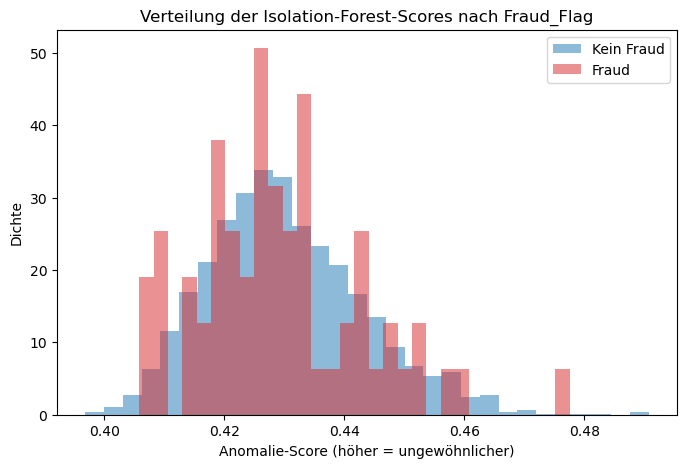

In [44]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
for flag, label, farbe in [(0, "Kein Fraud", "tab:blue"), (1, "Fraud", "tab:red")]:
    werte = luxury_datensatz.loc[luxury_datensatz["Fraud_Flag"] == flag, "Anomalie_Score"]
    ax.hist(werte, bins=30, density=True, alpha=0.5, label=label, color=farbe)

ax.set_xlabel("Anomalie-Score (höher = ungewöhnlicher)")
ax.set_ylabel("Dichte")
ax.set_title("Verteilung der Isolation-Forest-Scores nach Fraud_Flag")
ax.legend()
plt.show()

### Warum ist die Übereinstimmung mit Fraud_Flag so gering?

Der ROC-AUC von ~0,53 liegt praktisch auf Zufallsniveau (0,5 = Zufall). `IsolationForest` markiert Punkte als Anomalie, die in den Eingabemerkmalen ungewöhnlich sind — wenn `Fraud_Flag` nicht mit diesen Merkmalen zusammenhängt, kann das Modell Fraud-Fälle nicht besser als der Zufall erkennen. Wir prüfen das, indem wir die Mittelwerte der numerischen Merkmale zwischen Fraud- und Nicht-Fraud-Transaktionen vergleichen.

In [45]:
vergleich_mittelwerte = luxury_datensatz.groupby("Fraud_Flag")[numerische_merkmale].mean()
print(vergleich_mittelwerte)
print()
print(f"Eindeutige Customer_ID: {luxury_datensatz['Customer_ID'].nunique()} von {len(luxury_datensatz)} Zeilen")
print(f"Eindeutige IP_Address: {luxury_datensatz['IP_Address'].nunique()} von {len(luxury_datensatz)} Zeilen")

            Customer_Age  Purchase_Amount  Footfall_Count  Transaction_Stunde
Fraud_Flag                                                                   
0              41.682148       174.865104      271.966134           12.027576
1              42.257576       166.752273      287.984848           11.424242

Eindeutige Customer_ID: 2133 von 2133 Zeilen
Eindeutige IP_Address: 2133 von 2133 Zeilen


### Zusammenfassung & Handlungsempfehlungen

**Ergebnis:** Der `IsolationForest` markiert 66 Transaktionen (~3,09 %, wie durch `contamination` vorgegeben) als Anomalie, trifft davon aber nur 4 der 66 tatsächlichen Fraud-Fälle — der ROC-AUC von ~0,53 liegt auf Zufallsniveau. Die Mittelwerte von `Customer_Age`, `Purchase_Amount`, `Footfall_Count` und `Transaction_Stunde` unterscheiden sich zwischen Fraud- und Nicht-Fraud-Transaktionen kaum, ebenso die kategorischen Verteilungen (siehe Abschnitt I) — das `Fraud_Flag` in diesem Datensatz korreliert also praktisch nicht mit den vorhandenen Merkmalen.

**Handlungsempfehlungen:**

1. **Merkmale reichen nicht aus, um Fraud zu erklären.** Mit den aktuellen Transaktionsmerkmalen ist Betrugserkennung per Isolation Forest nicht sinnvoll möglich — bevor mehr Modellierungsaufwand investiert wird, sollte zuerst geprüft werden, ob überhaupt zusätzliche, aussagekräftigere Merkmale verfügbar sind.
2. **Verhaltensbasierte Merkmale erheben.** Da im Datensatz jede `Customer_ID` und `IP_Address` nur genau einmal vorkommt, lassen sich klassische Fraud-Signale wie Transaktionsfrequenz pro Kunde/IP, Geräte- oder Ortswechsel innerhalb kurzer Zeit oder Abweichung vom individuellen Kaufmuster nicht berechnen. Eine Datenerhebung mit mehreren Transaktionen pro Kunde wäre dafür Voraussetzung.
3. **Isolation Forest trotzdem als Qualitäts-Werkzeug nutzen.** Auch ohne Deckung mit `Fraud_Flag` markieren die gefundenen Anomalien strukturell ungewöhnliche Kombinationen der vorhandenen Merkmale (z. B. untypische Kombination aus Kategorie, Zahlungsart und Uhrzeit) und eignen sich als Ausgangspunkt für manuelle Stichprobenprüfung im Rahmen der Datenqualitätssicherung — unabhängig vom eigentlichen Fraud-Use-Case.
4. **`contamination` ist in Produktion nicht aus der Ground Truth ableitbar.** Hier konnte der Parameter anhand des bekannten `Fraud_Flag` gesetzt werden; ohne Label müsste er geschätzt oder anhand von Kapazität für manuelle Prüfungen festgelegt werden.
5. **Fehlende Werte gehören behoben, nicht nur erkannt.** Die Quality-Checks aus Abschnitt II decken zuverlässig auf, dass `Customer_Age`, `Customer_Loyalty_Tier` und `Payment_Method` unvollständig sind. Für den produktiven Einsatz müsste diesen Verstößen ein echter, dokumentierter Bereinigungsschritt folgen (z. B. Median-Imputation und ein expliziter Platzhalter für fehlende Kategorien) — hier wurde bewusst nur lokal für die Modellmatrix imputiert, damit die Quality-Checks weiterhin auf echten Rohdaten aufsetzen.

Damit ist die im Vorbericht gestellte Frage beantwortet: Datenprofiling und Quality-Checks decken die strukturellen Qualitätsprobleme dieses Datensatzes zuverlässig auf, aber die vorhandenen Merkmale reichen nicht aus, um die hier hinterlegten Betrugsmuster sichtbar zu machen — dafür wären zusätzliche, verhaltensbasierte Datenpunkte nötig.